In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path='/content/drive/MyDrive/diabetes.csv'
df=pd.read_csv(file_path)
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [ ]:
print(df.head())
print(df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


In [ ]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


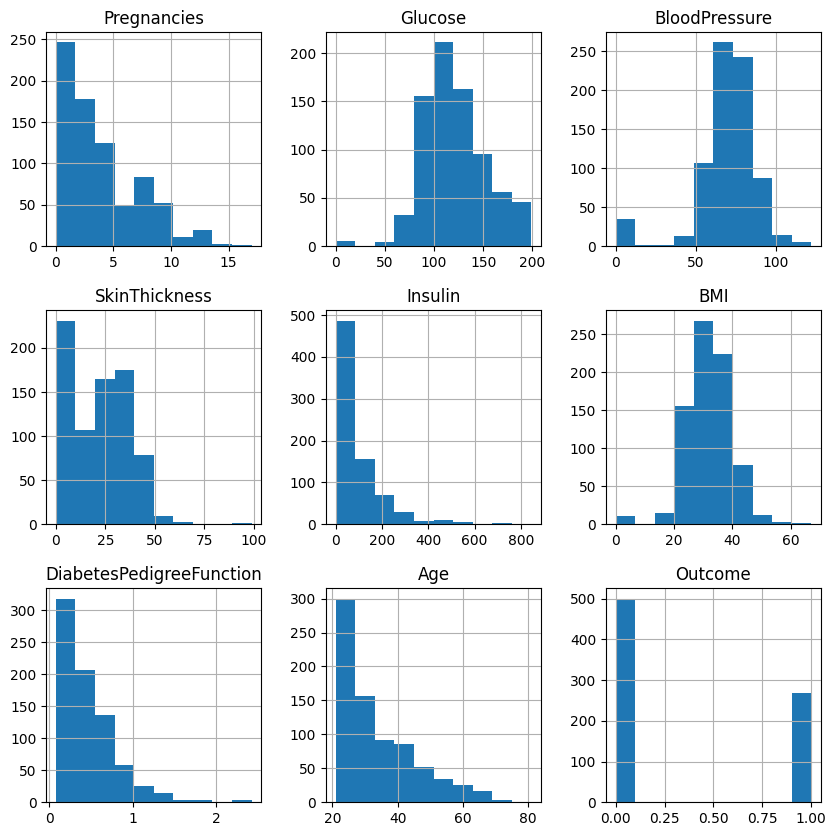

In [ ]:
df.hist(figsize=(10,10))
plt.show()

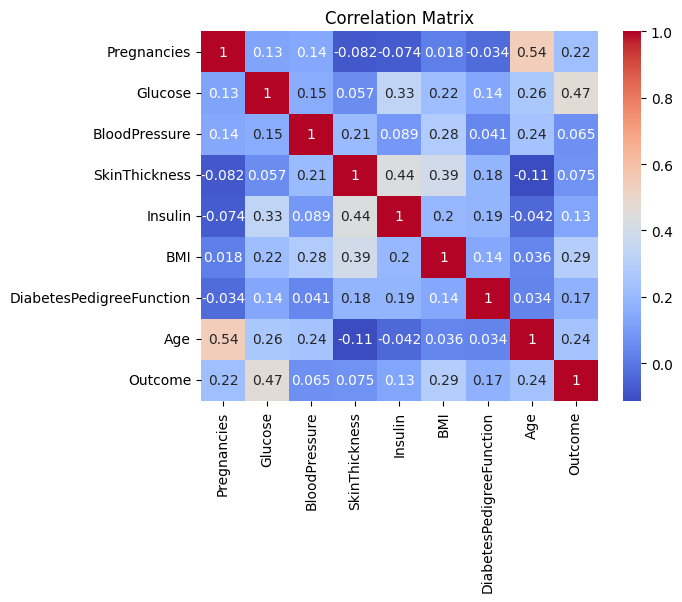

In [ ]:
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

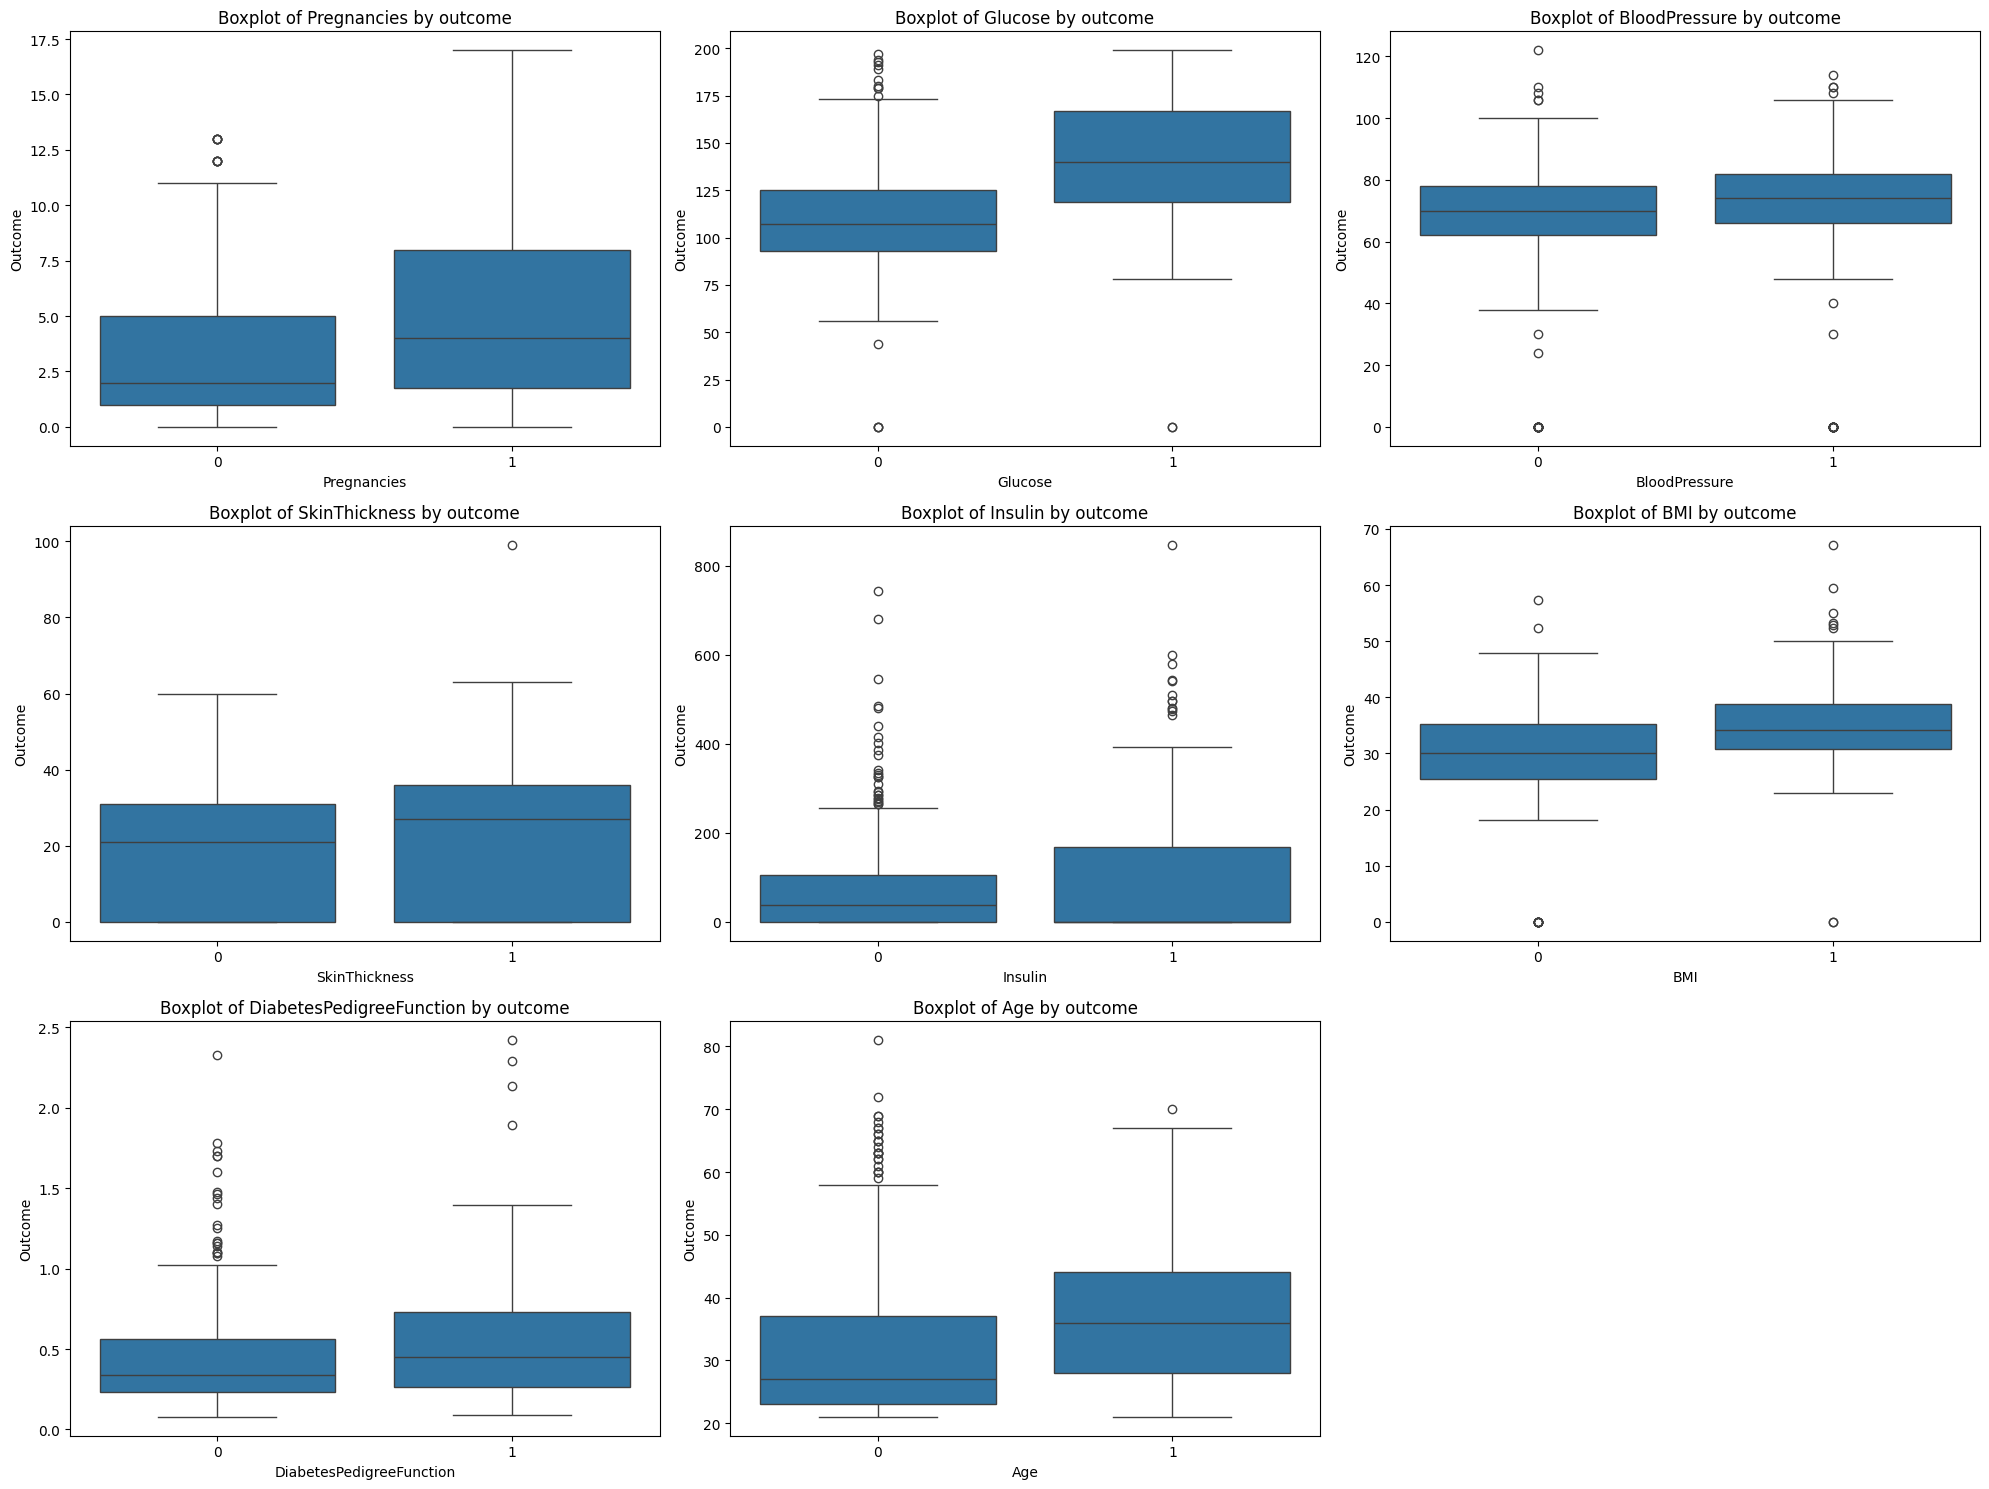

In [ ]:
features=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
target='Outcome'
plt.figure(figsize=(20,15))

for i,feature in enumerate(features,1):
  plt.subplot(3,3,i)
  sns.boxplot(x='Outcome',y=feature,data=df)
  plt.title(f'Boxplot of {feature} by outcome')
  plt.tight_layout()
  plt.xlabel(feature)
  plt.ylabel(target)
plt.show()

 Scatter Plot of Glucose vs BMI by Outcome 


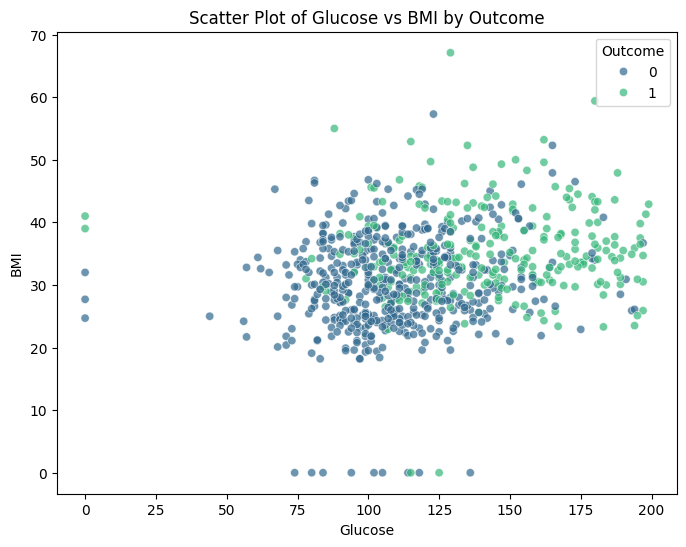

In [ ]:
print(" Scatter Plot of Glucose vs BMI by Outcome ")
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df, palette='viridis', alpha=0.7)
plt.title('Scatter Plot of Glucose vs BMI by Outcome')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.show()

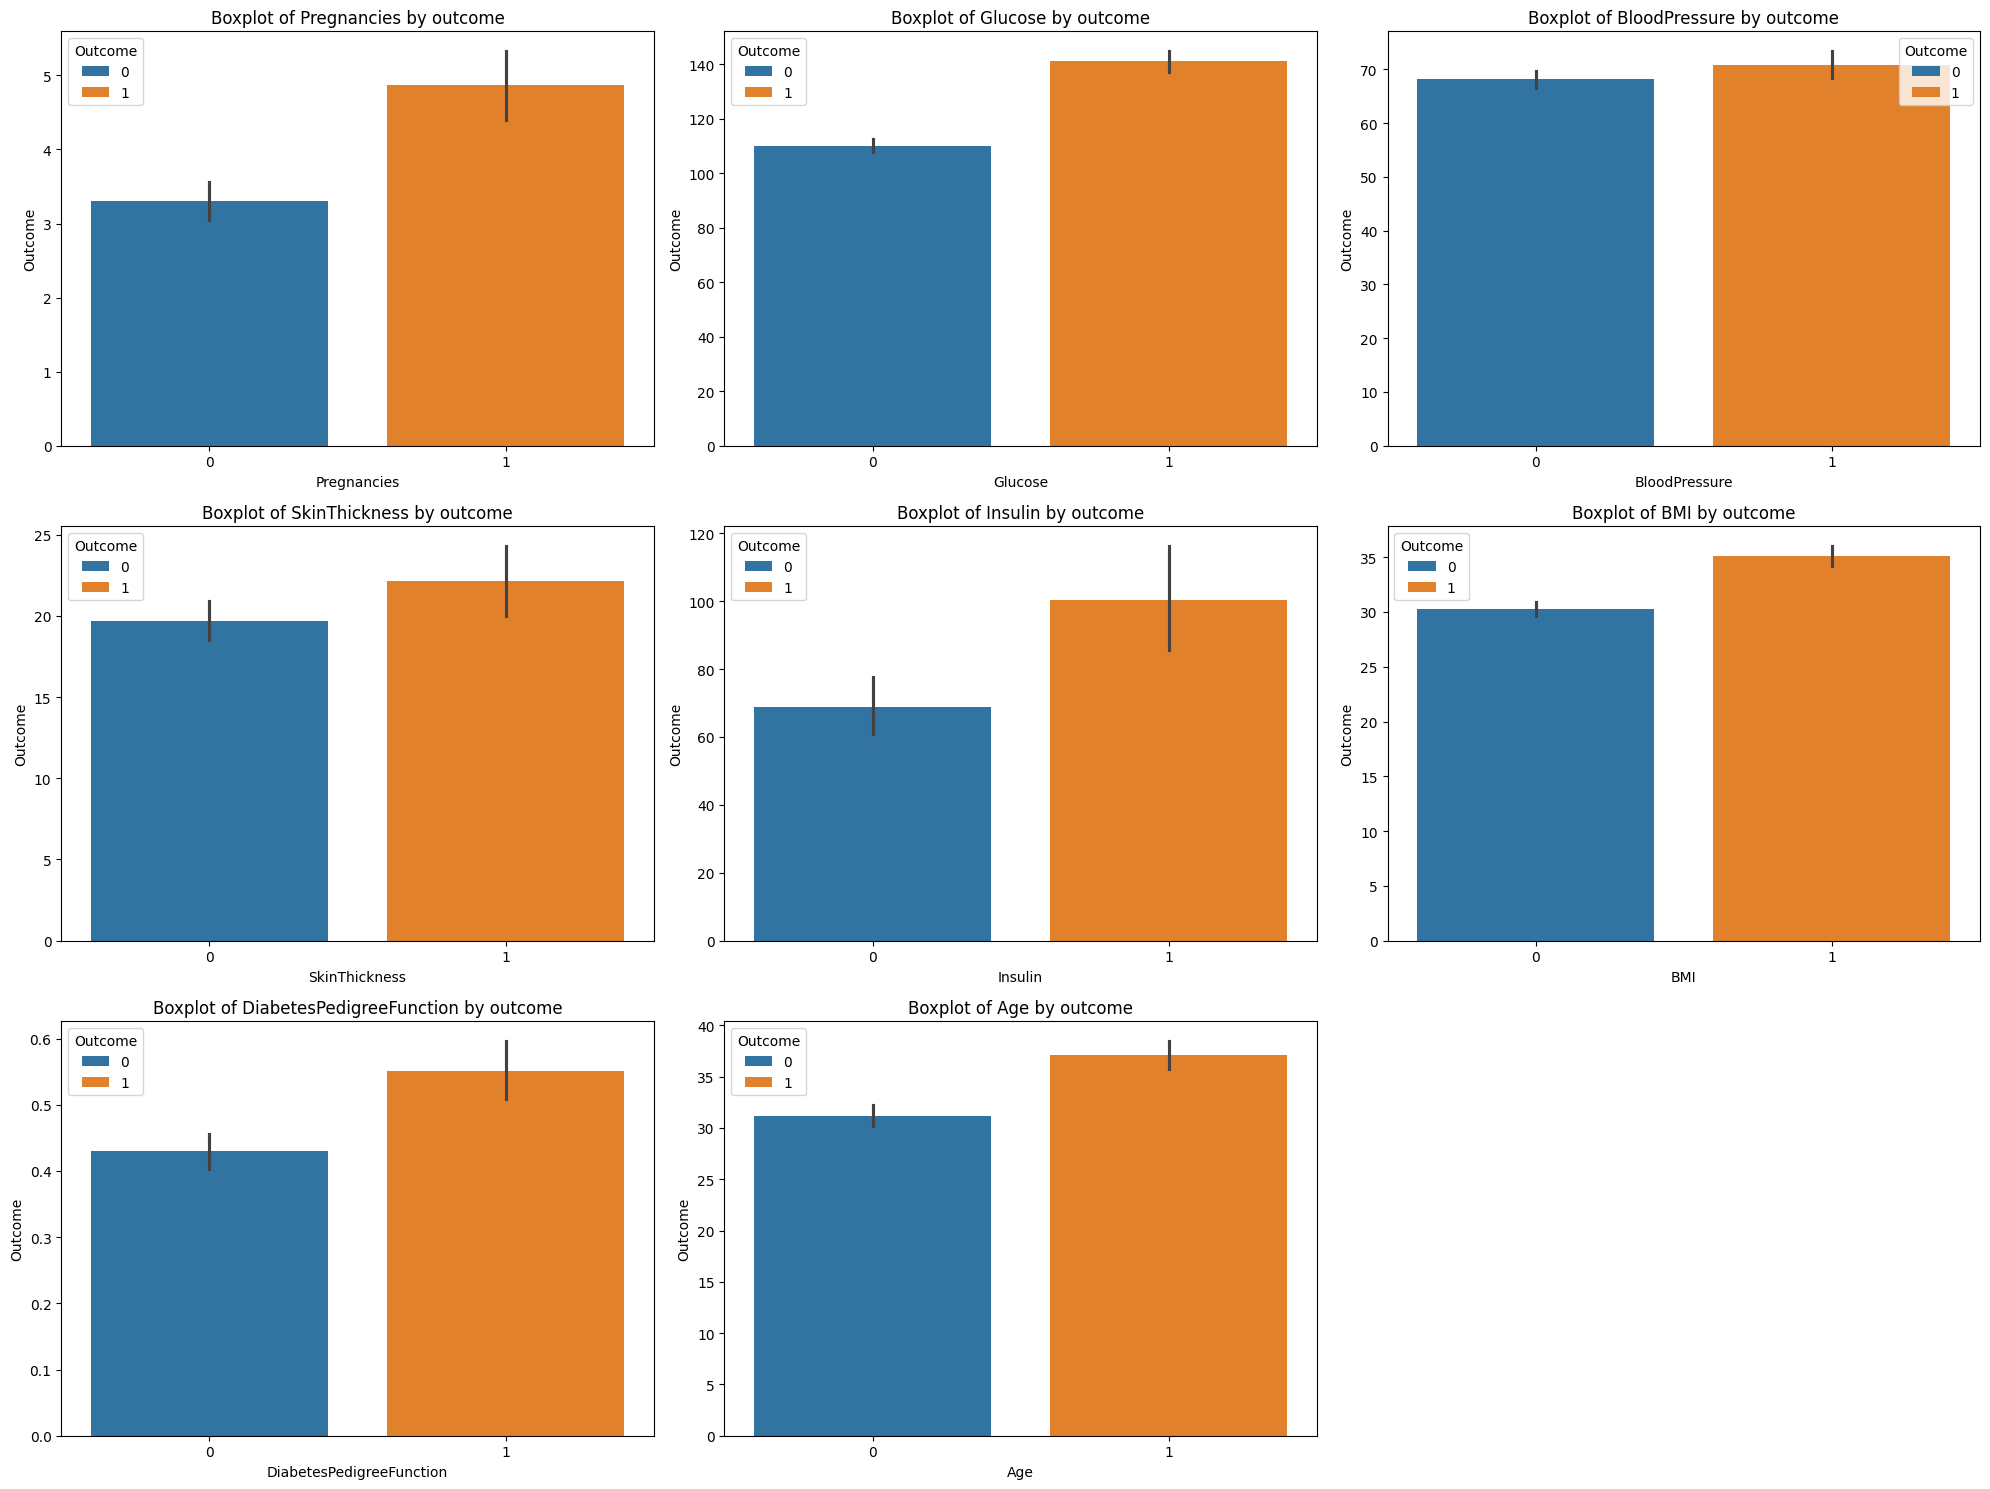

In [ ]:
features=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
target='Outcome'
plt.figure(figsize=(20,15))

for i,feature in enumerate(features,1):
  plt.subplot(3,3,i)
  sns.barplot(x='Outcome',y=feature,data=df,hue='Outcome')
  plt.title(f'Boxplot of {feature} by outcome')
  plt.tight_layout()
  plt.xlabel(feature)
  plt.ylabel(target)
plt.show()

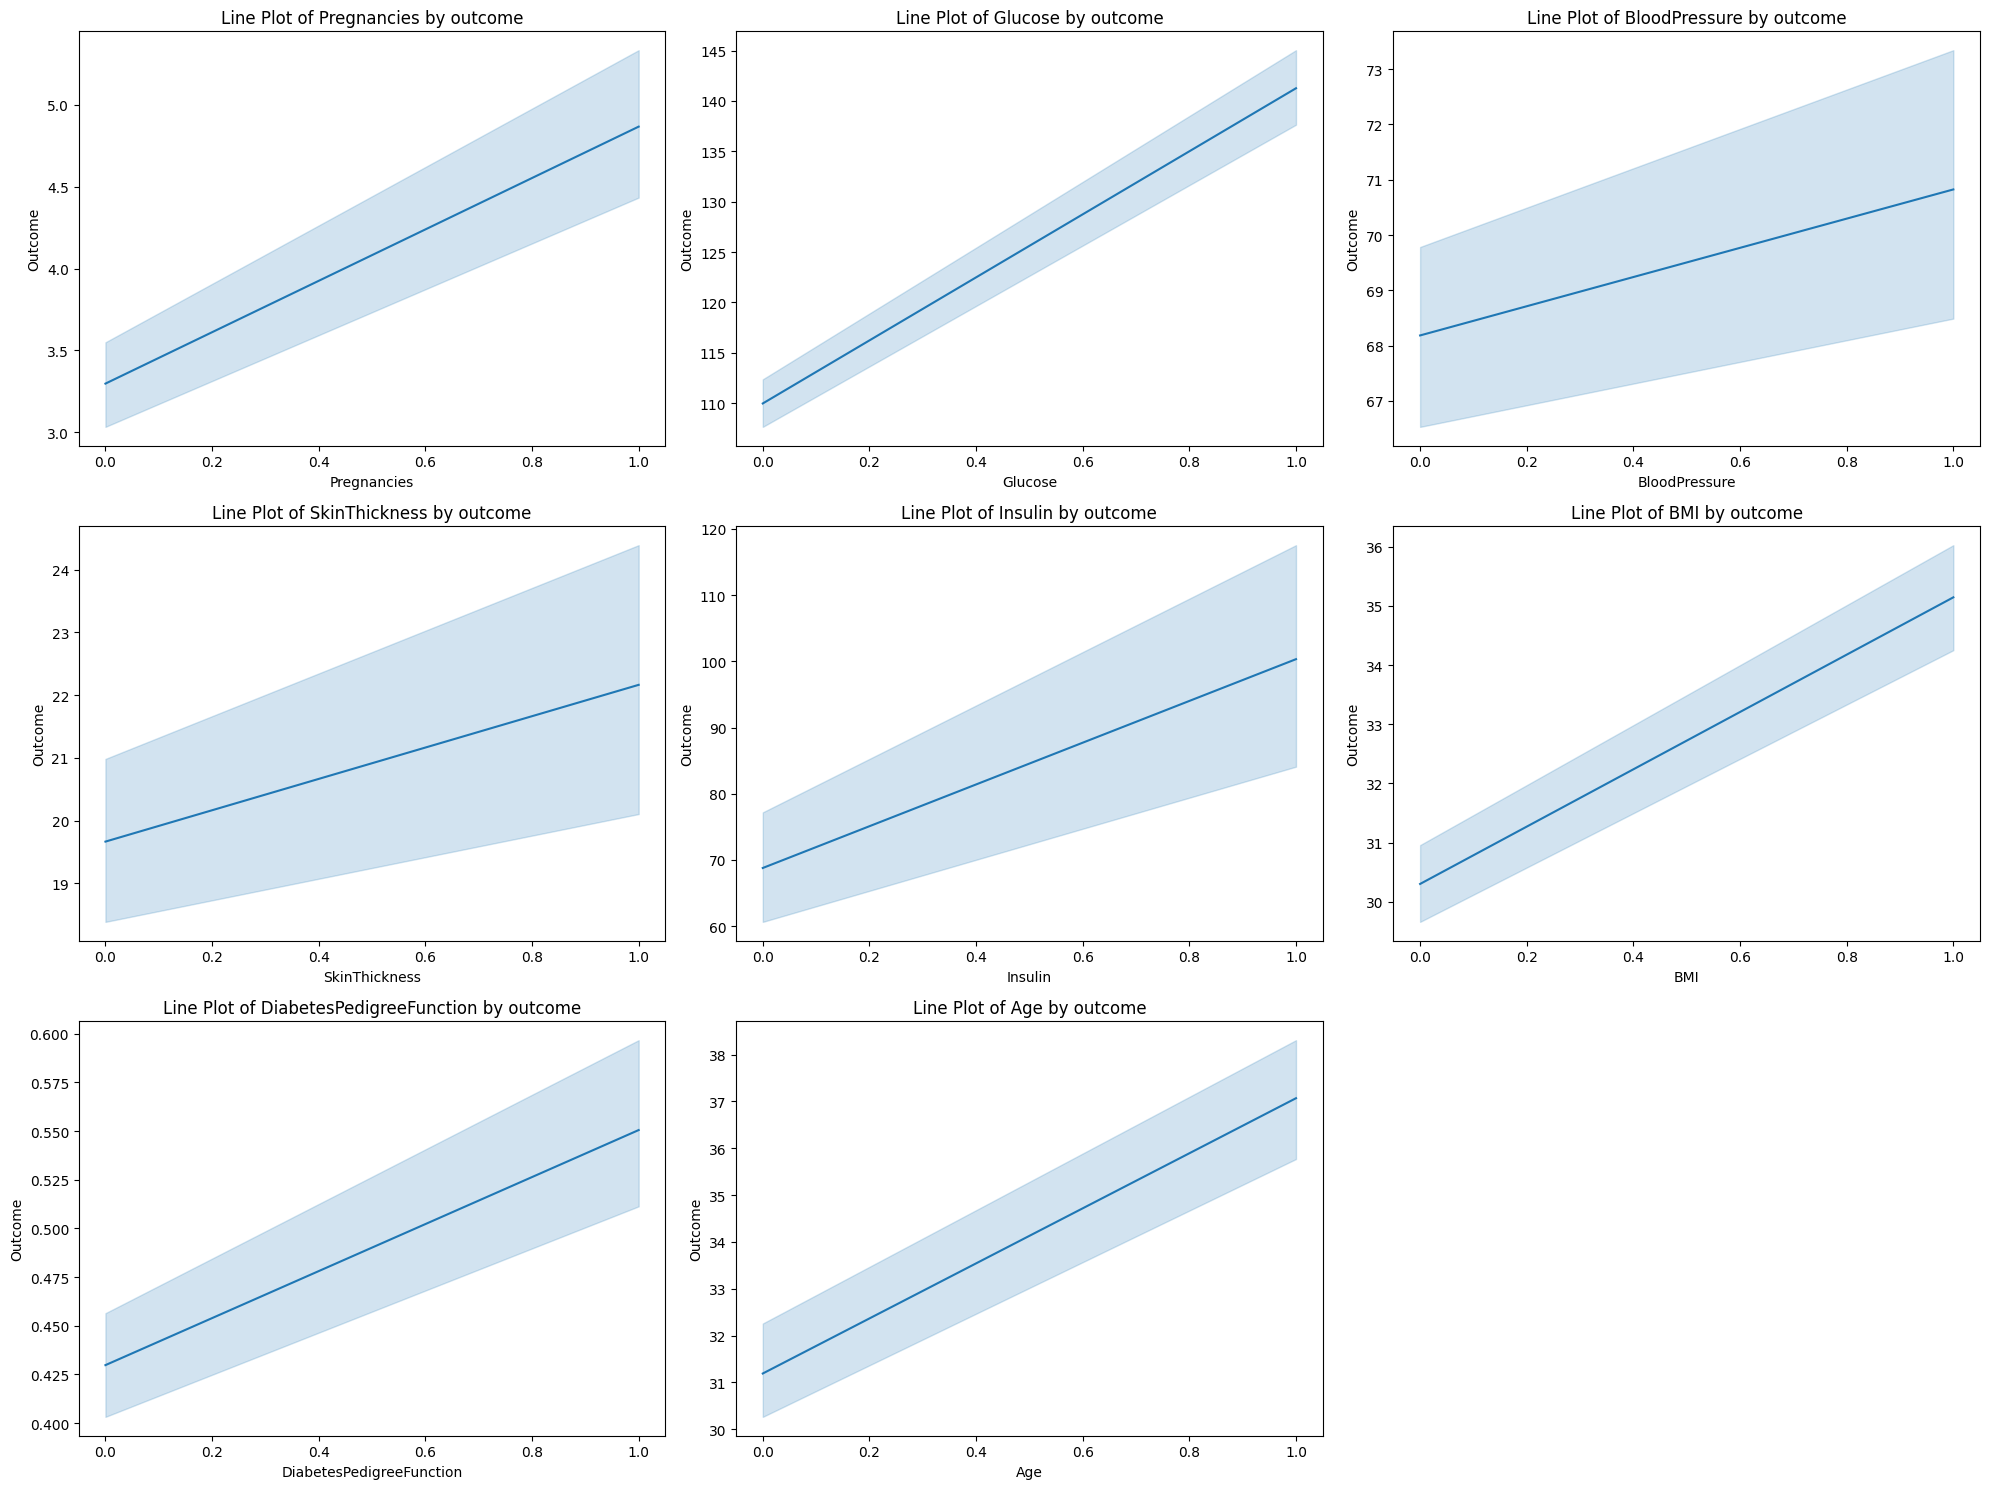

In [ ]:
features=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
target='Outcome'
plt.figure(figsize=(20,15))

for i,feature in enumerate(features,1):
  plt.subplot(3,3,i)
  sns.lineplot(x='Outcome',y=feature,data=df)
  plt.title(f'Line Plot of {feature} by outcome')
  plt.tight_layout()
  plt.xlabel(feature)
  plt.ylabel(target)
plt.show()

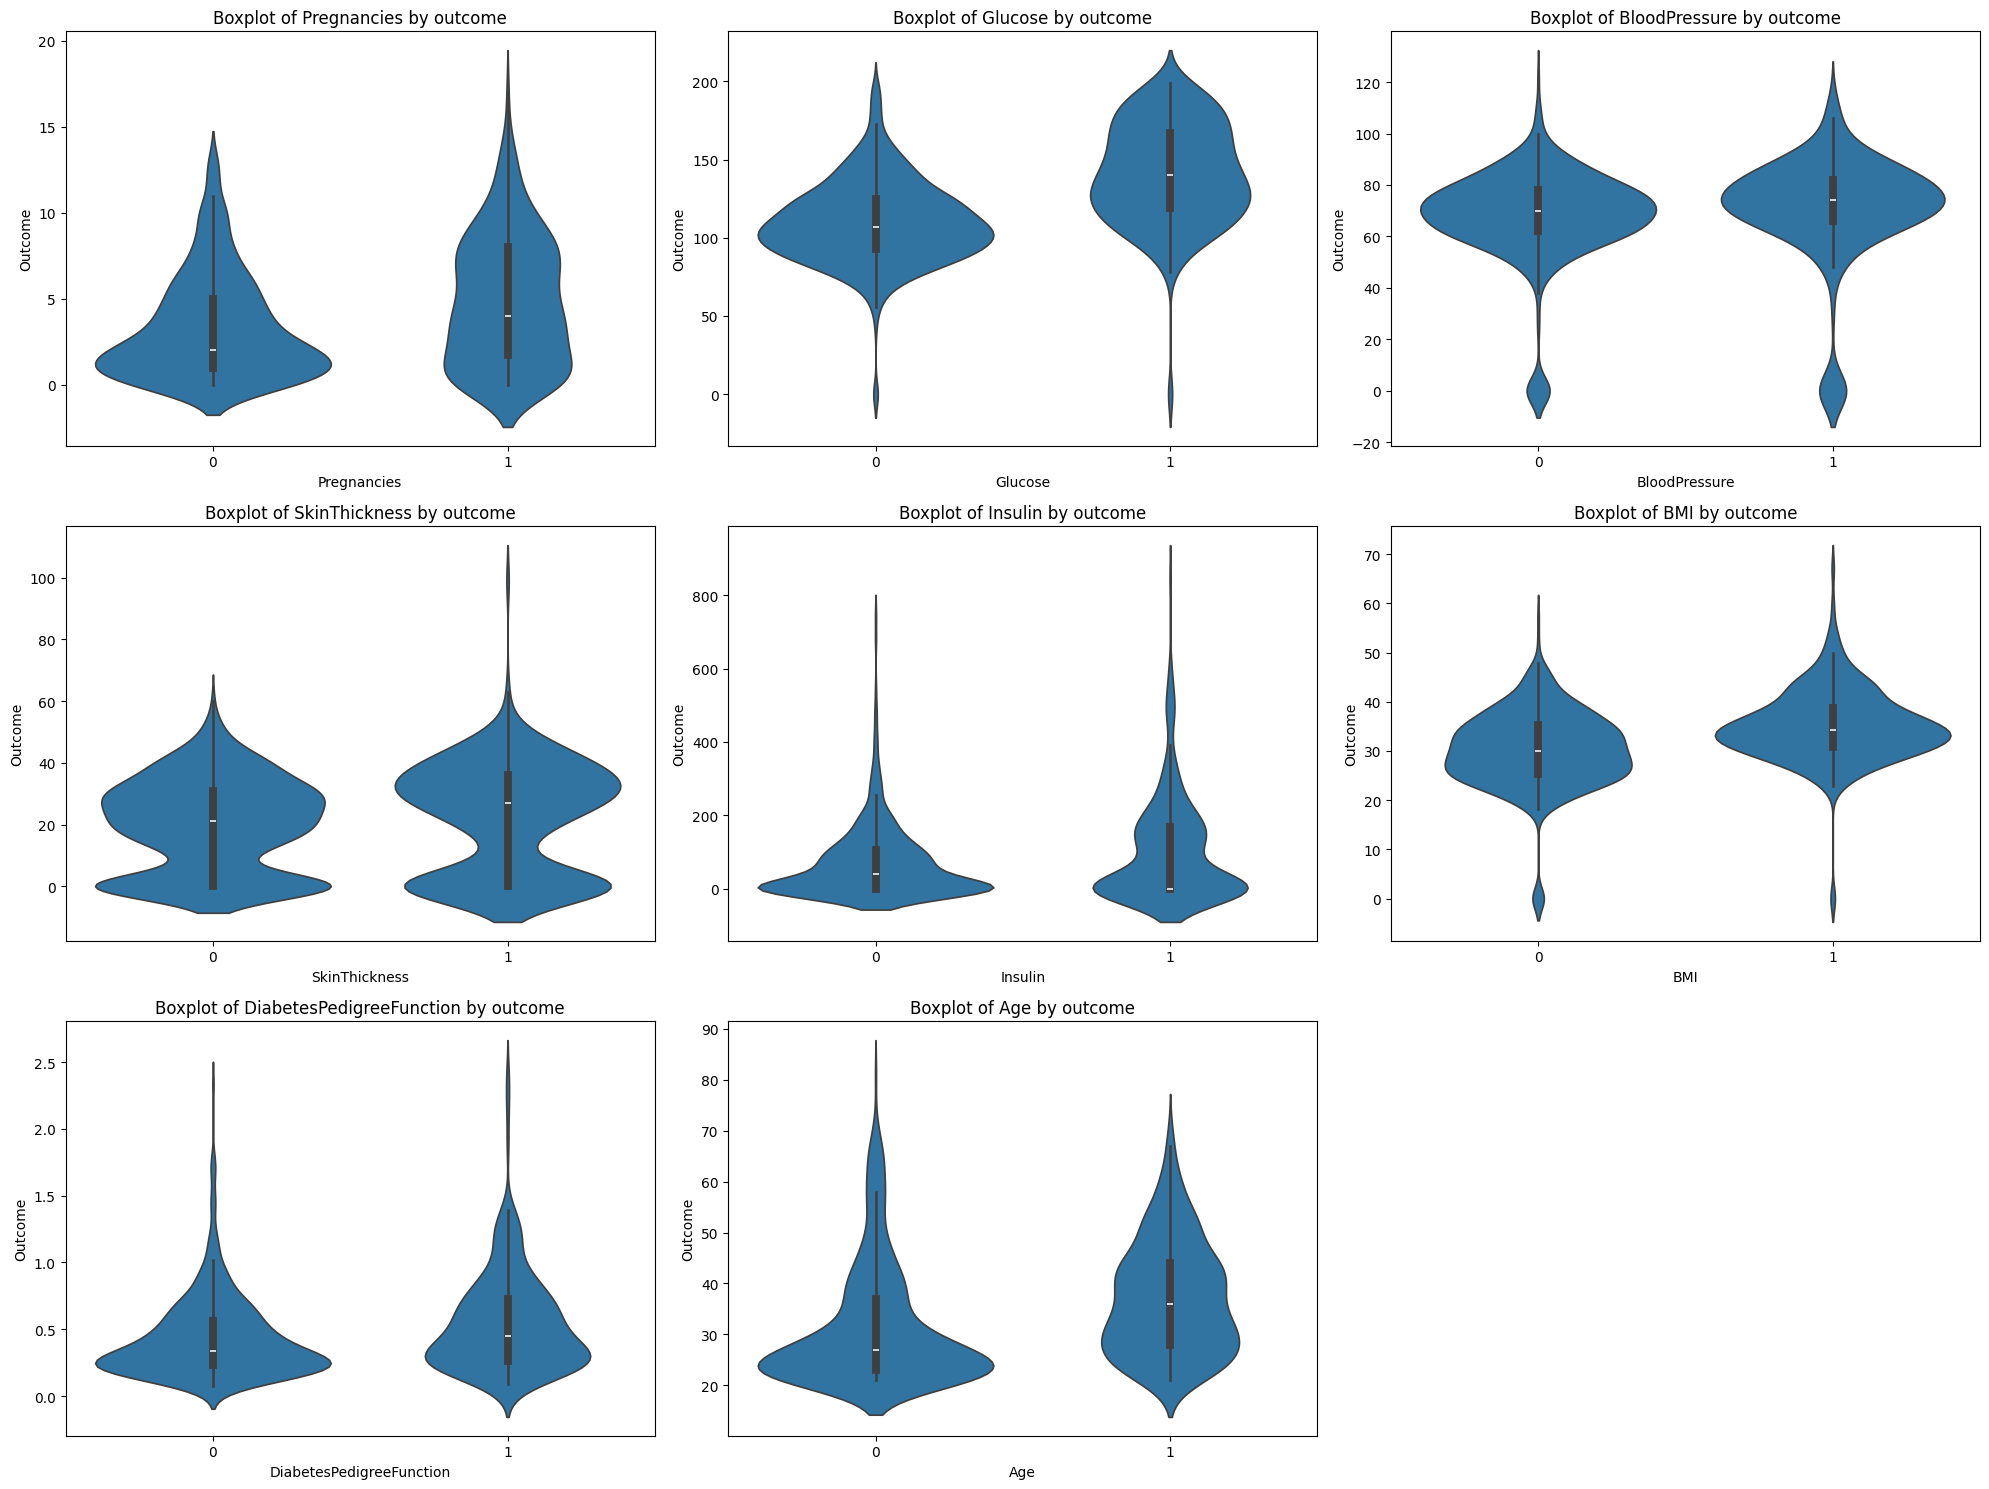

In [ ]:
features=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
target='Outcome'
plt.figure(figsize=(20,15))

for i,feature in enumerate(features,1):
  plt.subplot(3,3,i)
  sns.violinplot(x='Outcome',y=feature,data=df)
  plt.title(f'Boxplot of {feature} by outcome')
  plt.tight_layout()
  plt.xlabel(feature)
  plt.ylabel(target)
plt.show()

In [ ]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [ ]:
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred=knn.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy=accuracy_score(y_test,y_pred)
print("KNN Accuracy:",accuracy)

XGBoost Accuracy: 0.7532467532467533


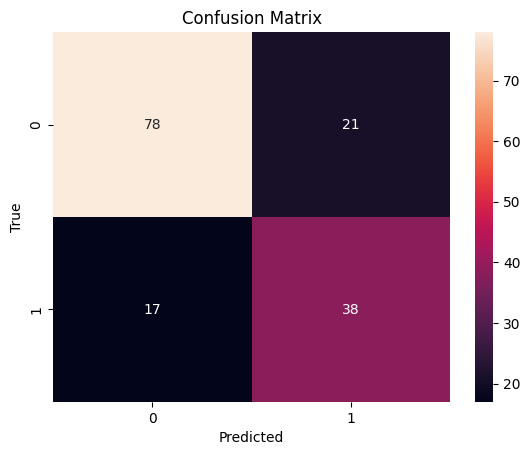

In [ ]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

accuracy=35+86/35+86+20+13

In [ ]:
def predict_outcome():
  featuress=[]
  for col in x.columns:
    value=float(input(f"Enter the value for {col}: "))
    featuress.append(value)

  featuress=np.array(featuress).reshape(1,-1)
  featuress=scaler.transform(featuress)
  prediction=dt.predict(featuress)
  if (prediction[0]==1):
    print("DIABETIC")
  else :
    print("NOT DIABETIC")

In [ ]:
predict_outcome()

Enter the value for Pregnancies: 23
Enter the value for Glucose: 45
Enter the value for BloodPressure: 25
Enter the value for SkinThickness: 46
Enter the value for Insulin: 27
Enter the value for BMI: 56
Enter the value for DiabetesPedigreeFunction: 89
Enter the value for Age: 42
DIABETIC


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
